In [142]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima import auto_arima
from sklearn.metrics import median_absolute_error,mean_absolute_percentage_error,mean_squared_error,root_mean_squared_error
import pickle


In [143]:
df = pd.read_csv("/workspaces/Elreno23-machine-learning-python-template/data/raw/10-time-series-forecasting-sales.csv")
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


### 1-Limpieza Inicial

In [144]:
df.duplicated().sum()

np.int64(0)

### 2-Preparación de Datos

In [145]:
df["date"]=pd.to_datetime(df["date"])
df["date"] = df["date"].dt.date
df = df.set_index("date")
df


,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633
...,...
2023-08-30,989.600354
2023-08-31,994.987326
2023-09-01,995.814415


### Conclusiones

Convertimos nuestra columna date a formato datetime y luego a date para eliminar las horas y minutos. Indexamos date y obtenemos un df de una sola columna.

### 3-Visualización Inicial

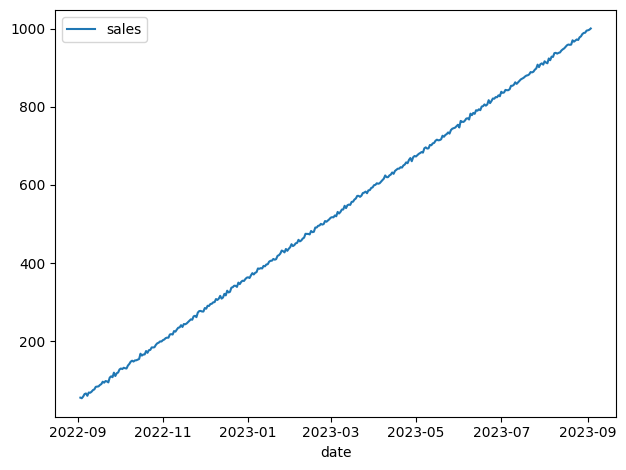

In [146]:
sns.lineplot(data=df)
plt.tight_layout()
plt.show()

### 4-Descomposición de la serie original
-Nos da una idea visual de tendencia y estacionalidad

In [147]:
descomposition = seasonal_decompose(df,period=7)
descomposition

##### Trend(Tendencia)

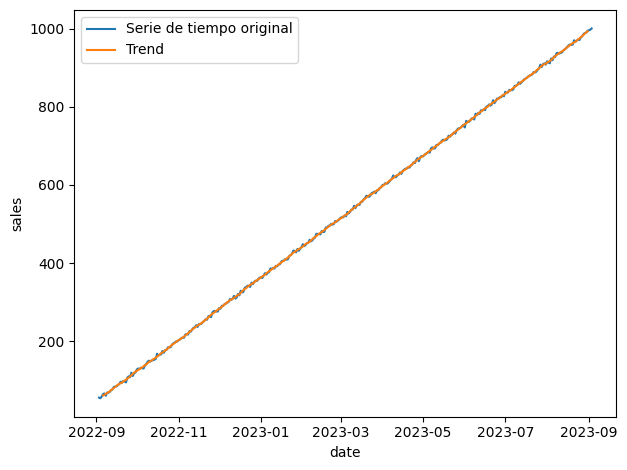

In [148]:
trend = descomposition.trend

sns.lineplot(x=df.index, y=df["sales"], label="Serie de tiempo original")
sns.lineplot(x=trend.index, y=trend.values, label="Trend")

plt.tight_layout()
plt.show()

##### Seasonal(Estacionalidad)

-Patrones repetitivos en intervalos irregulares

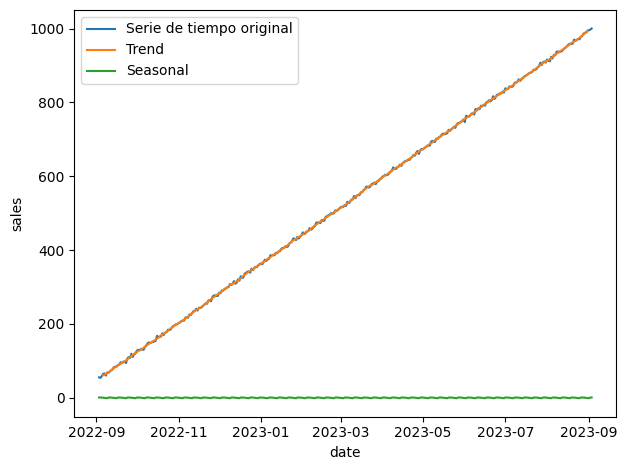

In [149]:
seasonal = descomposition.seasonal

sns.lineplot(x=df.index, y=df["sales"], label="Serie de tiempo original")
sns.lineplot(x=trend.index, y=trend.values, label="Trend")
sns.lineplot(x=seasonal.index,y=seasonal.values, label="Seasonal")

plt.tight_layout()
plt.show()

### 5-Test Dickey-Fuller aumentado

-Verificamos estacionariedad

In [150]:
def test_stationarity(timeseries):
    df_test = adfuller(timeseries, autolag="AIC")
    df_output = pd.Series(df_test[0:4], index=["Test Statistic", "p-value", "Lags Used", "Number of Observations Used"])
    for key, value in df_test[4].items():
        df_output[f'Critical Value {key}'] = value
    return df_output

result = test_stationarity(df)
result

Test Statistic                   0.545414
p-value                          0.986190
Lags Used                       13.000000
Number of Observations Used    352.000000
Critical Value 1%               -3.449065
Critical Value 5%               -2.869786
Critical Value 10%              -2.571163
dtype: float64

### Conclusiones
-Los valores que nos retorna el Test de Dickey-Fuller representan si la serie es estacionaria(valores estadisticos que cambian con el tiempo)
H0: NO estacionaria
H1: Estacionaria

Observamos que el valor p_value es muy alto por lo que no podemos rechazar H0(No es estacionaria)
Otra forma de verificar la estacionaridad es comparar el valor de Test Statistic con Critical Value 5% si este es mas negativo que el de Test Statistic quiere decir que rechazamos H0, la serie no es estacionaria


### 6-Diferenciación

-Estabilizamos la serie

In [151]:
df["diff_sales"] = df["sales"].diff()
sales_diff = df["diff_sales"].dropna()
sales_diff

date
2022-09-04   -1.488946
2022-09-05    4.338482
2022-09-06    6.389205
2022-09-07    1.482734
2022-09-08   -5.931768
                ...   
2023-08-30    0.518681
2023-08-31    5.386972
2023-09-01    0.827090
2023-09-02    1.535798
2023-09-03    3.132571
Name: diff_sales, Length: 365, dtype: float64

### Conclusiones

Calculamos la diferencia entre cada valor y el anterior, asi elimanamos la tendencia a largo plazo
Ejemplo: 
-Serie original: [100,120,140]
-Diferenciada: [NaN,20,20] -> Lo que logramos es que las propiedades estadisticas no cambien con el tiempo. Que sus valores se mantengan estables.



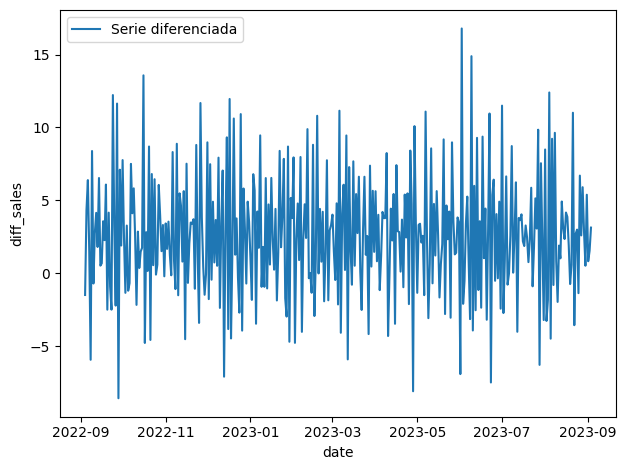

In [152]:
sns.lineplot(data=sales_diff, label="Serie diferenciada")
plt.tight_layout()
plt.show()

### 7-Test Dickey Fuller(Verificar Estacionaridad)

-Confirmamos que es esatcionaria

In [153]:
result_diff = test_stationarity(sales_diff)
result, result_diff

(Test Statistic                   0.545414
 p-value                          0.986190
 Lags Used                       13.000000
 Number of Observations Used    352.000000
 Critical Value 1%               -3.449065
 Critical Value 5%               -2.869786
 Critical Value 10%              -2.571163
 dtype: float64,
 Test Statistic                -9.430263e+00
 p-value                        5.212954e-16
 Lags Used                      1.200000e+01
 Number of Observations Used    3.520000e+02
 Critical Value 1%             -3.449065e+00
 Critical Value 5%             -2.869786e+00
 Critical Value 10%            -2.571163e+00
 dtype: float64)

### Conclusiones

Como podemos observar en este nuevo test podemos rechazar la H0, es decir, ahora la serie si es estacionaria, esto lo sabemos por los nuevos valores estadisticos. p-values es extremadamente bajo y Test Statistic es mucho mas negativo que Critical value 5%

### 8-Descomposición de la serie diferenciada

-Validamos como cambió al estructura despues de la transformación

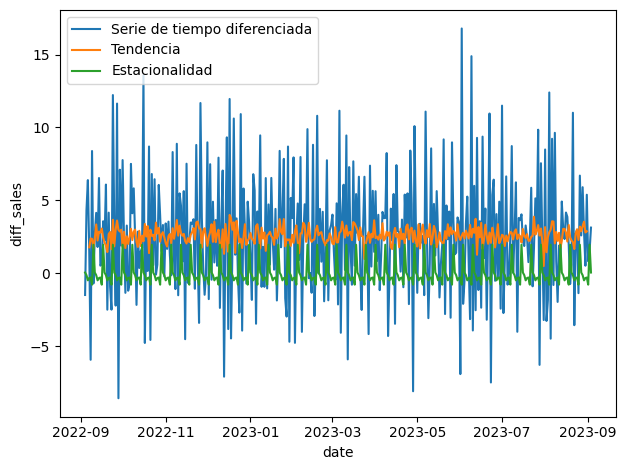

In [154]:
diff_descomposition= seasonal_decompose(sales_diff, period=7)
diff_descomposition_trend = diff_descomposition.trend
diff_descomposition_seasonal = diff_descomposition.seasonal
sns.lineplot(data=sales_diff,label="Serie de tiempo diferenciada")
sns.lineplot(data=diff_descomposition_trend,label="Tendencia")
sns.lineplot(data=diff_descomposition_seasonal,label="Estacionalidad")

plt.tight_layout()
plt.show()

In [155]:
df

,sales,diff_sales
date,,
2022-09-03,55.292157,NaN
2022-09-04,53.803211,-1.488946
2022-09-05,58.141693,4.338482
2022-09-06,64.530899,6.389205
2022-09-07,66.013633,1.482734
...,...,...
2023-08-30,989.600354,0.518681
2023-08-31,994.987326,5.386972
2023-09-01,995.814415,0.827090


### 9-Análisis de variabilidad

-residuo(Sin tendencia ni estacionalidad)
-Nos aseguramos que el ruido se comporta sin patrones claros

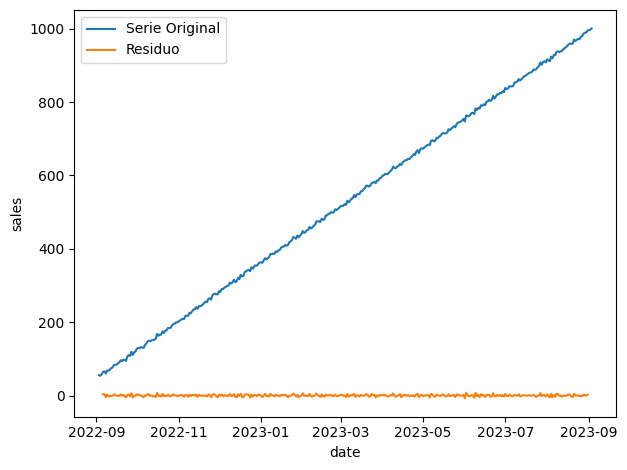

In [156]:
residual = descomposition.resid

sns.lineplot(x=df.index,y=df["sales"],label="Serie Original")
sns.lineplot(x=residual.index,y=residual.values,label="Residuo")

plt.tight_layout()
plt.show()


### Conclusiones

Residuo: Parte de la serie que no fue explicada por el modelo de descomposición

-Vemos la tendencia creciente de las ventas(linea azul)
-La linea naranja se mantiene en cero, lo que quiere decir que el modelo capturo bien la tendencia y estacionalidad, el residuo es minimo. el modelo está bien ajustado

#### 10-Análisis de la autocorrelación(ACF/PACF)

-Nos da una idea de los parametros a elegir para nuestro modelo


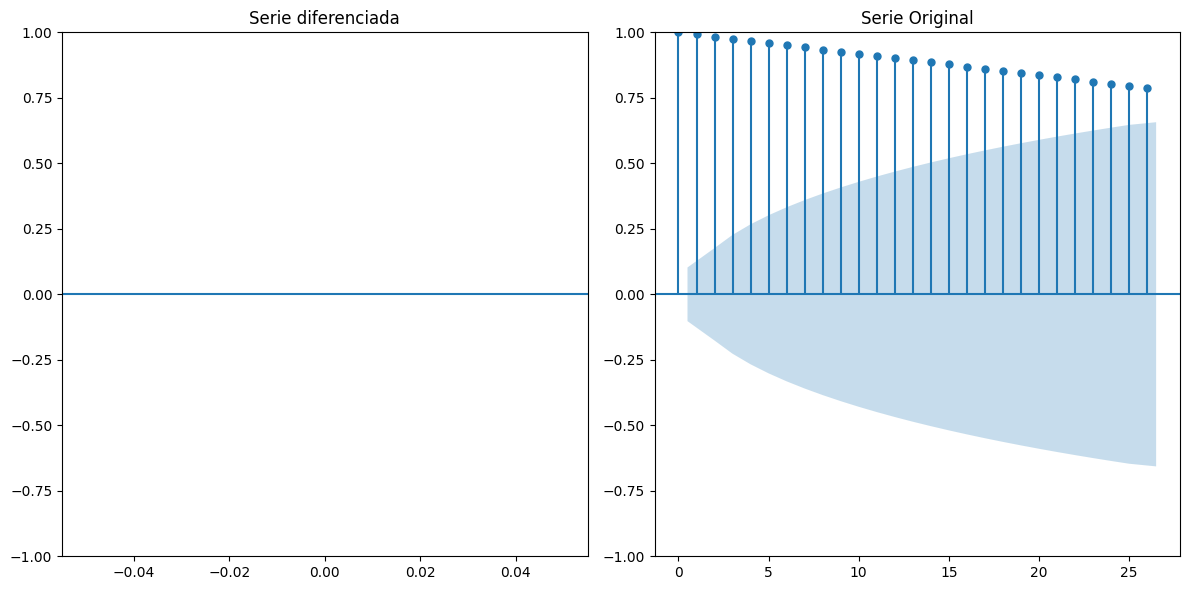

In [157]:
fig, axs = plt.subplots(1,2, figsize=(12,6))
plot_acf(df["diff_sales"], ax=axs[0])
axs[0].set_title("Serie diferenciada")
plot_acf(df["sales"],ax=axs[1])
axs[1].set_title("Serie Original")
plt.tight_layout()
plt.show()

### Conclusiones

-Despues de aplicar la diferenciacion a la serie, esta se ha vuelto estacionaria mostrando propiedades estadisticas constantes en el tiempo como podemos obervar en el grafico d ela izquierda

-En el grafico de la derecha observamos la serie original y esta presenta una tendencia, es decir, sus propiedades estadisticas(media, varianza) cambian con el tiempo(No estacionaria) 

### 11-Split

In [158]:
train = df["sales"][:-30] # Todo excepto últimos 30 días
test = df["sales"][-30:] # Últimos 30 días para evaluar

### Conclusiones
-30 dias es un periodo suficientemente largo para evaluar si el modelo capta tendencia, estacionalidad semanal y variaciones normales y suficientemnte corto para que el modelo no olvide el comportamiento reciente

### 12-Modelado

-Automatizamos la selección de parámetros con auto_arima

In [159]:
train_diff = train.diff().dropna() #Diferenciamos train
model = auto_arima(train_diff,seasonal=True,trace=True,m=7) #Datos diarios

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=1698.775, Time=0.93 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=1933.617, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=1816.473, Time=0.10 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=2035.035, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=1696.277, Time=0.90 sec
 ARIMA(2,0,2)(0,0,0)[7] intercept   : AIC=1698.340, Time=0.58 sec
 ARIMA(2,0,2)(0,0,2)[7] intercept   : AIC=1695.789, Time=1.91 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=1696.944, Time=1.70 sec
 ARIMA(1,0,2)(0,0,2)[7] intercept   : AIC=inf, Time=0.99 sec
 ARIMA(2,0,1)(0,0,2)[7] intercept   : AIC=1696.224, Time=1.57 sec
 ARIMA(3,0,2)(0,0,2)[7] intercept   : AIC=inf, Time=2.19 sec
 ARIMA(2,0,3)(0,0,2)[7] intercept   : AIC=inf, Time=1.25 sec
 ARIMA(1,0,1)(0,0,2)[7] intercept   : AIC=inf, Time=1.45 sec
 ARIMA(1,0,3)(0,0,2)[7] intercept   : AIC=inf, Time=1.54 s

### Conclusiones

-auto_arima -> Busca el mejor ARIMA/SARIMA
-sales_diff -> Serie temporal
-seasonal=True -> Incluye estacionalidad
-trace=true -> Muestra el proceso
-m=12 -> Ciclo estacional de 7 pasos(diarios)

##### -Informe estadistico

In [160]:
model.summary() #Nos da un "informe" estadistico del modelo

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  335
Model:             SARIMAX(2, 0, 2)x(0, 0, 2, 7)   Log Likelihood                -839.895
Date:                           Fri, 19 Dec 2025   AIC                           1695.789
Time:                                   17:52:02   BIC                           1726.302
Sample:                               09-04-2022   HQIC                          1707.954
                                    - 08-04-2023                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.3188      1.130      4.706      0.000       3.104       7.534
ar.L1         -0.9930      0.417     -2.379      0.017      -1.811      -0.175
ar.L2         -0.0537      0.056     -0.966      0.334      -0.163       0.055
ma.L1         -0.0465      0.408     -0.114      0.909      -0.846       0.753
ma.L2         -0.9301      0.407     -2.283      0.022      -1.729      -0.132
ma.S.L7        0.1600      0.060      2.679      0.007       0.043       0.277
ma.S.L14       0.0981      0.061      1.619      0.105      -0.021       0.217
sigma2         8.8251      0.732     12.062      0.000       7.391      10.259
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 0.44
Prob(Q):                              0.77   Prob(JB):                         0.80
Heteroskedasticity (H):               0.84   Skew:                             0.08
Prob(H) (two-sided):                  0.36   Kurtosis:                         2.91
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

##### 13-Generamos una proyección de la serie diferenciada

In [161]:
prediccion = model.predict(30)
prediccion

2023-08-05    0.730003
2023-08-06    2.303878
2023-08-07    1.730039
2023-08-08    3.605775
2023-08-09    1.804480
2023-08-10    2.360040
2023-08-11    3.617601
2023-08-12    2.500956
2023-08-13    2.673811
2023-08-14    1.992800
2023-08-15    3.192186
2023-08-16    1.952271
2023-08-17    2.109434
2023-08-18    3.665182
2023-08-19    2.355441
2023-08-20    2.568115
2023-08-21    2.642116
2023-08-22    2.557218
2023-08-23    2.637555
2023-08-24    2.562332
2023-08-25    2.632721
2023-08-26    2.566858
2023-08-27    2.628486
2023-08-28    2.570820
2023-08-29    2.624779
2023-08-30    2.574290
2023-08-31    2.621532
2023-09-01    2.577327
2023-09-02    2.618690
2023-09-03    2.579987
Freq: D, dtype: float64

#### Conclusiones
Valores pronosticados para cada fecha constantes

##### 14-Graficamos la serie diferenciada con la prediccion

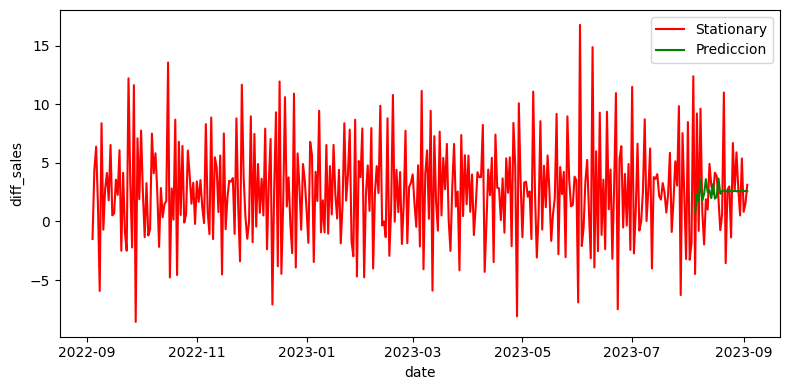

In [162]:
figs,axs=plt.subplots(figsize=(8,4))

sns.lineplot(data=sales_diff, label="Stationary", color="red")
sns.lineplot(data=prediccion, label="Prediccion", color="green")

plt.tight_layout()
plt.show()

##### 15-Revertimos la diferenciacion(Reconstruccion de Test) 
-Esto es la prediccion de test

In [163]:
#Ultimo valor de train antes de diferenciar
last_value = train.iloc[-1]

#Reconstruir las predicciones a partir del utlimo valor conocido

y_pred_test = prediccion.cumsum() + last_value
#cumsum(): Devuelve una nueva serie donde cada posición es la suma acumulada hasta ese punto.
y_pred_test

2023-08-05    924.466770
2023-08-06    926.770649
2023-08-07    928.500687
2023-08-08    932.106462
2023-08-09    933.910942
2023-08-10    936.270982
2023-08-11    939.888583
2023-08-12    942.389539
2023-08-13    945.063350
2023-08-14    947.056150
2023-08-15    950.248336
2023-08-16    952.200607
2023-08-17    954.310041
2023-08-18    957.975223
2023-08-19    960.330663
2023-08-20    962.898779
2023-08-21    965.540894
2023-08-22    968.098113
2023-08-23    970.735667
2023-08-24    973.297999
2023-08-25    975.930721
2023-08-26    978.497578
2023-08-27    981.126065
2023-08-28    983.696885
2023-08-29    986.321663
2023-08-30    988.895953
2023-08-31    991.517485
2023-09-01    994.094813
2023-09-02    996.713503
2023-09-03    999.293489
Freq: D, dtype: float64

#### Reconstrucción de Train

-Prediccion de train

In [164]:
pred_diff_train = model.predict_in_sample() #"Dame tus predicciones dentro del train, usando los datos con los que te entrené"

'''pred_diff_train devuelve 335 valores(no coincide con train), esto se debe a que ARIMA
no puede predecir el primer punto de train, ya que no tiene rezagos. Por eso necesitamos insetar
un valor(0) manualmente en el siguiente bloque para poder obtener las metricas de train tambien'''
if len(pred_diff_train) < len(train): pred_diff_train = pd.concat([pd.Series([0]), pred_diff_train], ignore_index=True)

first_value = train.iloc[0] #Punto de partida para reconstruir train

#Reconstruye la serie original de train
#pred_diff_train.cumsum():
'''Convierte las diferencias en valores acumulados'''
#+ first_value:
'''Le suma el primer valor real del train'''
y_pred_train = pred_diff_train.cumsum() + first_value #Prediccion de train en escala original

pred_diff_train

0       0.000000
1       2.598696
2       4.741185
3       2.795997
4      -0.301544
         ...    
331    -0.810803
332     5.721885
333    -0.257182
334     6.944642
335    10.044650
Length: 336, dtype: float64

### Conclusiones

-La diferenciación es un paso tecnico para que la serie sea estacionaria(propiedades estadisticas constantes) y asi el modelo pueda trabajr bien, pero lo que nos interesa es predecir las ventas originales, por eso hay que revertir las diferenciación

-Obtenemos el ultimo valor de la columna "sales"(columna original estacionaria)

-Obtenemos la suma acumulada de la prediccion de la serie no estacionaria mas este ultimo valor

-Estamos prediciendo las diferencias de las ventas originales, a partir del ultimo valor original


##### 16-Graficamos la prediccion con al serie original

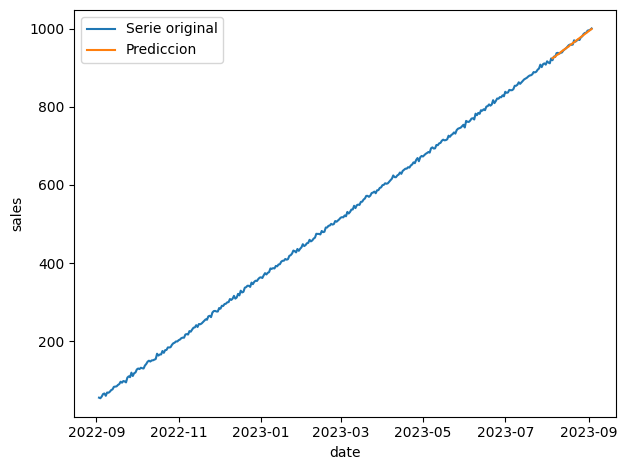

In [165]:
sns.lineplot(data=df["sales"], label="Serie original")
sns.lineplot(data=y_pred_test, label="Prediccion")

plt.tight_layout()
plt.show()

### Conclusiones

-El modelo captó al tendencia y sigue la trayectoria ascendete de la serie original

### 17-Metricas

In [166]:
def get_regression_metrics(y_predict_test, y_test, y_predict_train, y_train):
    metrics_train = (median_absolute_error(y_train, y_predict_train),
                     mean_absolute_percentage_error(y_train, y_predict_train) * 100,
                     mean_squared_error(y_train, y_predict_train),
                     root_mean_squared_error(y_train, y_predict_train))
    metrics_test = (median_absolute_error(y_test, y_predict_test),
                    mean_absolute_percentage_error(y_test, y_predict_test) * 100,
                    mean_squared_error(y_test, y_predict_test),
                    root_mean_squared_error(y_test, y_predict_test))
    metrics_diff = list(map(lambda x: x[1] - x[0], zip(metrics_train, metrics_test)))
    return pd.DataFrame(data=[metrics_train, metrics_test, metrics_diff],
                        columns=['MAE', 'MAPE', 'MSE', 'RMSE'],
                        index=['Train set', 'Test set', 'Difference'])
    

result = get_regression_metrics(y_pred_test, test, y_pred_train,train)
result

,MAE,MAPE,MSE,RMSE
Train set,43.344603,13.595254,2384.434384,48.830671
Test set,1.547048,0.220490,6.834196,2.614230
Difference,-41.797555,-13.374764,-2377.600188,-46.216441


### Conclusiones
-Observamos que el error en train es alto(MAE=43 Y RMSE=48) lo que nos indica que no está aprendiendo bien del pasado pero tambien es buena señal ya que no hay sobreajuste.
-Tambien vemos que el modelo funciona mejor en test que en train, ya que las diferencias son negativas lo que nos puede indicar que el mdelo generaliza bien y predice mejor el futuro que el pasado

### 18-Guardado

In [167]:
import pickle

with open("../models/arima_sales.pkl", "wb") as f:
    pickle.dump(model, f)

### Tensor en uan serie temporal

-Cada cuanto ocurre un dato(dia,semnana,mes,etc). La manera mas simple es mirar las fechas, y podemos aplicar inferred_freq que nos lo dice directamente.

-En este caso los datos son diarios pero el comportamiento se repite cada 7 dias.